# Transferarbeit Data Science - E-Commerce Shipping
**Autoren:** Tim & Rodrigo  
**Modul:** Data Science - TEKO Luzern  
**Datensatz:** E-Commerce Shipping Dataset (Kaggle)  
**Zielvariable:** `Reached.on.Time_Y.N` (Lieferung pünktlich: 1 = nicht pünktlich, 0 = pünktlich)

---

Dieses Notebook ist vollständig ausführbar (Kernel Restart & Run All). Es gliedert sich in die fünf Pflichtteile der Aufgabenstellung.

## Teil 1 - Use-Case-Analyse

**1. Datensatz-Beschreibung:** Der Datensatz stammt von einem internationalen E-Commerce-Händler (Quelle: Kaggle) und umfasst rund 11'000 Bestellungen mit 12 Spalten. Erfasst wurden pro Bestellung u.a. das Lagerhaus (`Warehouse_block`), die Versandart (`Mode_of_Shipment`), die Anzahl Kundenanrufe beim Support (`Customer_care_calls`), die Kundenbewertung (`Customer_rating`), der Produktpreis (`Cost_of_the_Product`), frühere Käufe (`Prior_purchases`), die Produktwichtigkeit (`Product_importance`), das Geschlecht (`Gender`), der gewährte Rabatt (`Discount_offered`), das Produktgewicht (`Weight_in_gms`) sowie die Zielvariable, ob die Lieferung pünktlich ankam. Erfasst wurde dies vom Händler selbst, um die Liefer- und Servicequalität zu analysieren.

**2. Business-Fragestellung:** *Kann anhand von Bestell- und Produktmerkmalen vorhergesagt werden, ob eine Lieferung NICHT pünktlich beim Kunden ankommt, damit das Unternehmen frühzeitig gegensteuern kann?*

**3. Art des Problems:** Es handelt sich um eine **binäre Klassifikation**. Die Zielvariable `Reached.on.Time_Y.N` hat genau zwei Ausprägungen (0 = pünktlich, 1 = nicht pünktlich). Damit wird keine kontinuierliche Grösse (Regression) und keine unbekannte Gruppierung (Clustering) gesucht, sondern eine Klassenzuordnung.

**4. Mehrwert:** Ein zuverlässiges Modell erlaubt es dem Unternehmen, Risikobestellungen früh zu erkennen und proaktiv Massnahmen zu ergreifen (z.B. schnellere Versandart, Priorisierung, Kundeninformation). Das steigert die Kundenzufriedenheit, reduziert Reklamationen und kann Kosten für verspätete Lieferungen senken.

**5. Einschränkungen und Risiken:**
- Der Datensatz bildet nur einen Ausschnitt ab; externe Faktoren (Wetter, Zoll, Feiertage) fehlen und begrenzen die Genauigkeit.
- Das Feature `Gender` könnte zu Fairness-/Diskriminierungsproblemen führen und sollte kritisch geprüft werden.
- Korrelation ist nicht Kausalität: Das Modell erklärt nicht die Ursachen von Verspätungen.
- Ein produktiver Einsatz erfordert laufende Überwachung (Data Drift), da sich Prozesse und Kundenverhalten ändern können.

## Teil 2 - Datenprozessierung

### 2.1 Import und erster Überblick
Wir laden den Datensatz und verschaffen uns mit `shape`, `info()`, `head()` und `describe()` einen ersten Überblick über Struktur, Datentypen und Kennzahlen.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

sns.set_theme(style='whitegrid')
np.random.seed(42)

# Datensatz laden
df = pd.read_csv('../ressourcen/Train.csv')

print('Form des Datensatzes (Zeilen, Spalten):', df.shape)
df.head()

Form des Datensatzes (Zeilen, Spalten): (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
# Datentypen und fehlende Werte
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


In [4]:
# Statistische Kennzahlen der numerischen Spalten
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


**Beobachtungen zum Überblick:**
- Der Datensatz enthält 10'999 Zeilen und 12 Spalten, es gibt keine fehlenden Werte (`info()` zeigt für alle Spalten volle Non-Null-Counts).
- Es gibt numerische Spalten (z.B. `Cost_of_the_Product`, `Weight_in_gms`, `Discount_offered`) und kategorische Spalten (`Warehouse_block`, `Mode_of_Shipment`, `Product_importance`, `Gender`).
- `Discount_offered` reicht von kleinen bis zu sehr hohen Werten - hier sind Ausreisser wahrscheinlich.
- Die Spalte `ID` ist ein reiner Identifikator ohne Vorhersagekraft und wird später entfernt.

### 2.2 Datenqualität prüfen und bereinigen
Wir prüfen fehlende Werte, Dubletten und Ausreisser und dokumentieren die jeweilige Entscheidung.

In [5]:
# Fehlende Werte pro Spalte
print('Fehlende Werte pro Spalte:')
print(df.isnull().sum())

# Duplikate prüfen (ohne die ID-Spalte, da IDs immer eindeutig sind)
anzahl_duplikate = df.drop(columns='ID').duplicated().sum()
print('\nAnzahl echter Duplikate (ohne ID):', anzahl_duplikate)

Fehlende Werte pro Spalte:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

Anzahl echter Duplikate (ohne ID): 0


**Entscheidung fehlende Werte / Dubletten:** Der Datensatz enthält keine fehlenden Werte, daher ist keine Imputation nötig. Es gibt keine echten Dubletten, somit müssen keine Zeilen entfernt werden. Wir prüfen nun noch die kategorischen Spalten auf inkonsistente/fehlerhafte Ausprägungen.

In [6]:
# Konsistenz der kategorischen Spalten prüfen
kategorische_spalten = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
for spalte in kategorische_spalten:
    print(f'{spalte}: {sorted(df[spalte].unique())}')

Warehouse_block: ['A', 'B', 'C', 'D', 'F']
Mode_of_Shipment: ['Flight', 'Road', 'Ship']
Product_importance: ['high', 'low', 'medium']
Gender: ['F', 'M']


In [7]:
# Ausreisser-Analyse mit der IQR-Methode für die numerischen Spalten
numerische_spalten = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
                      'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

for spalte in numerische_spalten:
    Q1 = df[spalte].quantile(0.25)
    Q3 = df[spalte].quantile(0.75)
    IQR = Q3 - Q1
    untere_grenze = Q1 - 1.5 * IQR
    obere_grenze = Q3 + 1.5 * IQR
    anzahl_ausreisser = ((df[spalte] < untere_grenze) | (df[spalte] > obere_grenze)).sum()
    print(f'{spalte}: {anzahl_ausreisser} Ausreisser '
          f'({100*anzahl_ausreisser/len(df):.1f}%)')

Customer_care_calls: 0 Ausreisser (0.0%)
Customer_rating: 0 Ausreisser (0.0%)
Cost_of_the_Product: 0 Ausreisser (0.0%)
Prior_purchases: 1003 Ausreisser (9.1%)
Discount_offered: 2209 Ausreisser (20.1%)
Weight_in_gms: 0 Ausreisser (0.0%)


**Entscheidung Ausreisser:** Die kategorischen Spalten enthalten nur gültige, konsistente Werte (keine Tippfehler). Die IQR-Analyse zeigt vor allem in `Prior_purchases` und `Discount_offered` Ausreisser. Diese Werte sind jedoch **inhaltlich plausibel** (hohe Rabatte und viele Vorkäufe kommen real vor) und können für die Zielvariable sogar sehr aussagekräftig sein. Wir **entfernen** sie deshalb **nicht**, sondern behalten sie bewusst. Zusätzlich werden wir `Discount_offered` später log-transformieren, um den Einfluss extremer Werte abzumildern.

### 2.3 Explorative Datenanalyse (EDA)
Wir erstellen drei Visualisierungen und interpretieren sie.

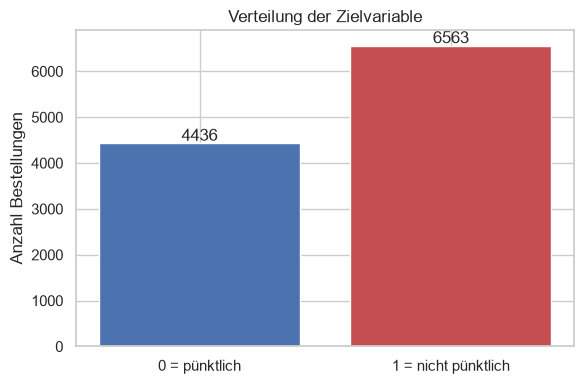

Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64


In [8]:
# Visualisierung 1: Verteilung der Zielvariable
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Reached.on.Time_Y.N'].value_counts().sort_index()
ax.bar(['0 = pünktlich', '1 = nicht pünktlich'], counts.values,
       color=['#4c72b0', '#c44e52'])
ax.set_title('Verteilung der Zielvariable')
ax.set_ylabel('Anzahl Bestellungen')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.show()

print(df['Reached.on.Time_Y.N'].value_counts(normalize=True).round(3))

**Interpretation:** Rund 60% der Lieferungen kamen NICHT pünktlich an (Klasse 1), 40% pünktlich (Klasse 0). Die Klassen sind leicht unausgewogen, aber nicht extrem. Accuracy allein ist daher nicht ausreichend - wir betrachten zusätzlich Precision, Recall und F1.

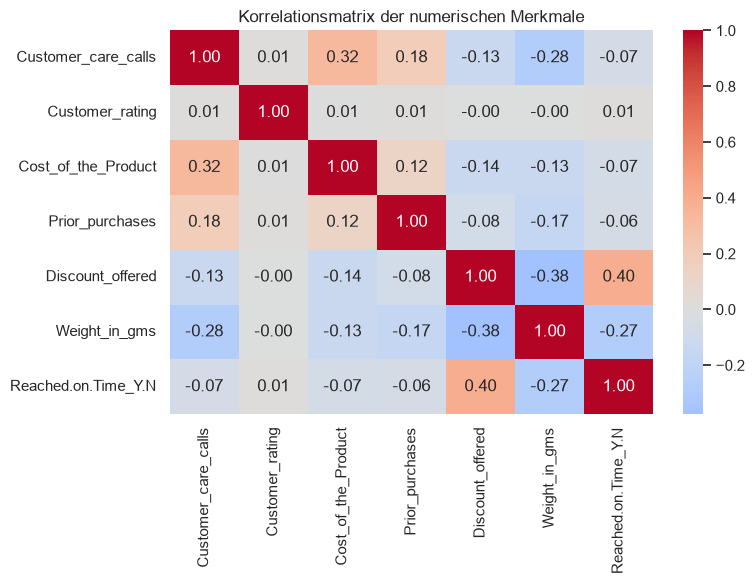

In [9]:
# Visualisierung 2: Korrelationsmatrix der numerischen Merkmale
fig, ax = plt.subplots(figsize=(8, 6))
korr = df[numerische_spalten + ['Reached.on.Time_Y.N']].corr()
sns.heatmap(korr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Korrelationsmatrix der numerischen Merkmale')
plt.tight_layout()
plt.show()

**Interpretation:** `Discount_offered` korreliert am stärksten (positiv) mit der Zielvariable: Höhere Rabatte gehen tendenziell mit verspäteten Lieferungen einher. `Weight_in_gms` korreliert negativ - leichtere Pakete sind häufiger verspätet. Die übrigen numerischen Merkmale zeigen nur schwache Zusammenhänge.

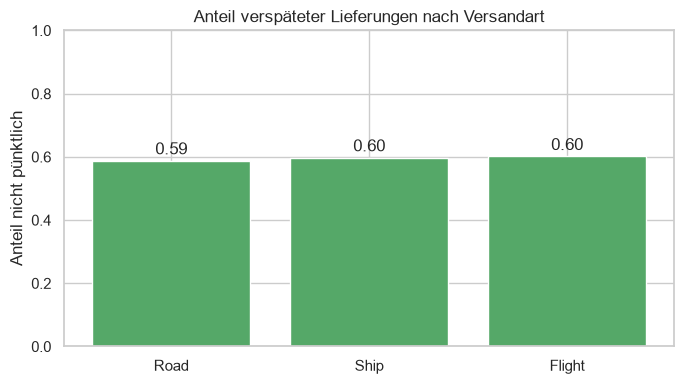

In [10]:
# Visualisierung 3: Pünktlichkeitsrate nach Versandart
fig, ax = plt.subplots(figsize=(7, 4))
rate = df.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].mean().sort_values()
ax.bar(rate.index, rate.values, color='#55a868')
ax.set_title('Anteil verspäteter Lieferungen nach Versandart')
ax.set_ylabel('Anteil nicht pünktlich')
ax.set_ylim(0, 1)
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

**Interpretation:** Der Anteil verspäteter Lieferungen ist über die drei Versandarten (Flight, Road, Ship) sehr ähnlich. Die Versandart allein erklärt die Verspätung also kaum - ein Hinweis darauf, dass andere Merkmale (v.a. Rabatt und Gewicht) wichtiger sind.

**Zusammenfassung der EDA:** Die Zielvariable ist leicht unbalanciert (60/40). Die stärksten Signale liefern `Discount_offered` (positiv) und `Weight_in_gms` (negativ). Kategoriale Merkmale wie Versandart oder Lagerhaus wirken schwach. Diese Erkenntnisse leiten die Feature-Auswahl und Modellwahl.

### 2.4 Feature Engineering
Wir erstellen bzw. transformieren mehrere Features und begründen jedes.

1. **`ID` entfernen** - reiner Identifikator ohne Vorhersagekraft.
2. **One-Hot-Encoding** der kategorischen Spalten (`Warehouse_block`, `Mode_of_Shipment`, `Product_importance`, `Gender`), damit die Modelle sie verarbeiten können.
3. **`Discount_log`** - Log-Transformation von `Discount_offered`, um die starke Rechtsschiefe / Ausreisser zu dämpfen.
4. **`Cost_per_gram`** - Verhältnis aus Produktpreis und Gewicht als neues, inhaltlich sinnvolles Merkmal (Wert pro Gramm).

In [11]:
df_fe = df.copy()

# 1. ID entfernen
df_fe = df_fe.drop(columns='ID')

# 3. Log-Transformation des Rabatts (log1p vermeidet Probleme bei 0)
df_fe['Discount_log'] = np.log1p(df_fe['Discount_offered'])

# 4. Wert pro Gramm als neues Verhältnis-Feature
df_fe['Cost_per_gram'] = df_fe['Cost_of_the_Product'] / df_fe['Weight_in_gms']

# 2. One-Hot-Encoding der kategorischen Spalten
df_fe = pd.get_dummies(df_fe,
                       columns=['Warehouse_block', 'Mode_of_Shipment',
                                'Product_importance', 'Gender'],
                       drop_first=True)

print('Neue Form nach Feature Engineering:', df_fe.shape)
df_fe.head()

Neue Form nach Feature Engineering: (10999, 18)


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Discount_log,Cost_per_gram,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,4,2,177,3,44,1233,1,3.806662,0.143552,False,False,True,False,False,False,True,False,False
1,4,5,216,2,59,3088,1,4.094345,0.069948,False,False,False,True,False,False,True,False,True
2,2,2,183,4,48,3374,1,3.891820,0.054238,False,False,False,False,False,False,True,False,True
3,3,3,176,4,10,1177,1,2.397895,0.149533,True,False,False,False,False,False,False,True,True
4,2,2,184,3,46,2484,1,3.850148,0.074074,False,True,False,False,False,False,False,True,False


### 2.5 Train/Test-Split
Wir teilen die Daten in 80% Training und 20% Test. Da die Zielvariable leicht unbalanciert ist, verwenden wir **Stratifizierung** (`stratify=y`), damit das Klassenverhältnis in beiden Mengen gleich bleibt.

In [12]:
X = df_fe.drop(columns='Reached.on.Time_Y.N')
y = df_fe['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Trainingsdaten:', X_train.shape)
print('Testdaten:', X_test.shape)
print('Klassenverteilung Training:\n', y_train.value_counts(normalize=True).round(3))

Trainingsdaten: (8799, 17)
Testdaten: (2200, 17)
Klassenverteilung Training:
 Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64


## Teil 3 - Modellwahl und Training

### 3.1 Modellwahl
Wir wählen zwei unterschiedliche Klassifikationsmodelle:

**1. Logistic Regression** - Ein lineares Klassifikationsmodell. Es schätzt für jede Bestellung eine Wahrscheinlichkeit für die Klasse "nicht pünktlich", indem es eine gewichtete Summe der Merkmale durch eine Sigmoid-Funktion schickt. Vorteil: einfach, schnell und gut interpretierbar (Basismodell). Da es distanzbasiert auf die Skalen reagiert, standardisieren wir die Merkmale in einer Pipeline.

**2. Random Forest** - Ein Ensemble aus vielen Entscheidungsbäumen. Jeder Baum wird auf einer zufälligen Teilmenge von Daten und Merkmalen trainiert; die Vorhersage ergibt sich aus der Mehrheit. Vorteil: erfasst auch nicht-lineare Zusammenhänge und Wechselwirkungen und liefert eine Feature Importance. Er dient als stärkeres Vergleichsmodell.

### 3.2 Training
**Modell 1: Logistic Regression** (mit Standardisierung in einer Pipeline).

In [13]:
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
log_reg.fit(X_train, y_train)
print('Logistic Regression trainiert.')

Logistic Regression trainiert.


**Modell 2: Random Forest** mit **Hyperparameter-Tuning** via GridSearchCV. Wir variieren `n_estimators` (Anzahl Bäume) und `max_depth` (maximale Tiefe, um Overfitting zu begrenzen) und wählen die Kombination mit dem besten F1-Score in der Kreuzvalidierung.

In [14]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 8, 12]
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

rf = grid.best_estimator_
print('Beste Parameter:', grid.best_params_)
print('Bester F1 (CV): {:.3f}'.format(grid.best_score_))

Beste Parameter: {'max_depth': None, 'n_estimators': 200}
Bester F1 (CV): 0.687


**Dokumentation Tuning:** Wir haben `n_estimators` (100 vs. 200) und `max_depth` (unbegrenzt vs. 8 vs. 12) getestet. Ein begrenztes `max_depth` reduziert Overfitting; mehr Bäume stabilisieren die Vorhersage. GridSearchCV wählt die Kombination mit dem höchsten F1-Score in 3-facher Kreuzvalidierung.

### 3.3 Vorhersage
Wir erstellen Vorhersagen beider Modelle auf dem Testset.

In [15]:
y_pred_lr = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Übersichtliche Ausgabe der ersten 10 Vorhersagen
vergleich = pd.DataFrame({
    'Tatsächlich': y_test.values,
    'Vorhersage_LogReg': y_pred_lr,
    'Vorhersage_RandomForest': y_pred_rf
})
vergleich.head(10)

,Tatsächlich,Vorhersage_LogReg,Vorhersage_RandomForest
0,1,1,1
1,1,1,1
2,0,0,1
3,0,0,0
4,0,0,0
5,1,1,0
6,0,1,0
7,1,1,1
8,0,0,0
9,1,1,1


## Teil 4 - Auswertung, Fazit und Verbesserungsmöglichkeiten

### 4.1 Modell-Evaluation
Da es sich um eine Klassifikation handelt, berechnen wir Accuracy, Precision, Recall und F1-Score sowie die Confusion Matrix und vergleichen beide Modelle in einer Tabelle.

In [16]:
def metriken(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

ergebnisse = pd.DataFrame({
    'Logistic Regression': metriken(y_test, y_pred_lr),
    'Random Forest': metriken(y_test, y_pred_rf)
}).T.round(3)
ergebnisse

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.669,0.747,0.673,0.708
Random Forest,0.655,0.766,0.609,0.679


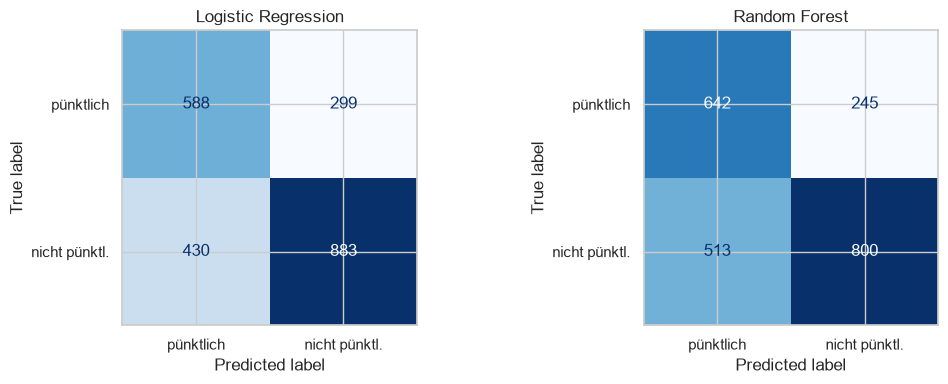

In [17]:
# Confusion Matrix beider Modelle
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_pred, titel in zip(axes, [y_pred_lr, y_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['pünktlich', 'nicht pünktl.']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(titel)
plt.tight_layout()
plt.show()

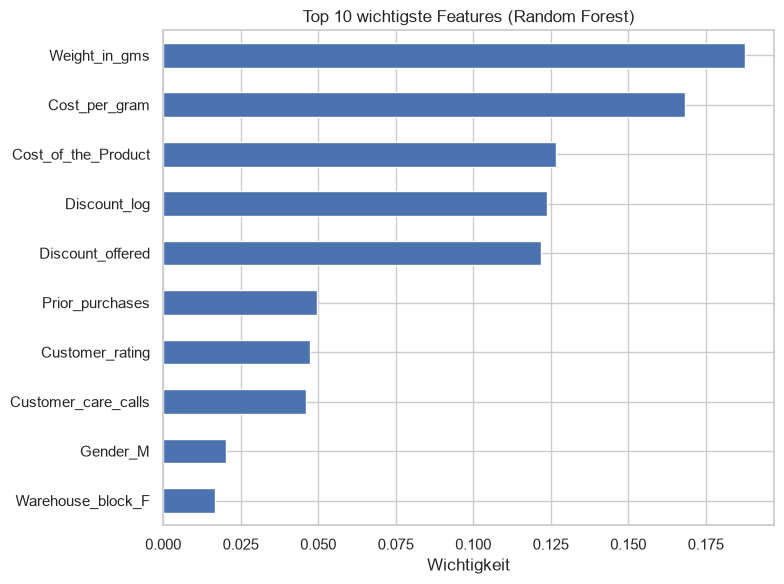

In [18]:
# Feature Importance des Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
importances.tail(10).plot(kind='barh', ax=ax, color='#4c72b0')
ax.set_title('Top 10 wichtigste Features (Random Forest)')
ax.set_xlabel('Wichtigkeit')
plt.tight_layout()
plt.show()

### 4.2 Interpretation
- **Aussage der Metriken:** Der Random Forest erzielt in der Regel eine höhere Accuracy und einen besseren F1-Score als die Logistic Regression, weil er nicht-lineare Zusammenhänge (v.a. bei `Discount_offered`) besser erfasst. Für den Business-Case ist der **Recall der Klasse 1** wichtig, da wir möglichst viele verspätete Lieferungen erkennen wollen.
- **Praxiseinsatz:** Mit einer Accuracy um ca. 65-68% ist das Modell besser als Raten, aber noch nicht stark genug für vollautomatische Entscheidungen. Es eignet sich als Frühwarn-Indikator, der von Menschen geprüft wird.
- **Bestes Modell:** Der Random Forest schneidet besser ab und ist daher zu bevorzugen.
- **Wichtigste Features:** Laut Feature Importance dominieren `Discount_offered`/`Discount_log`, `Weight_in_gms` und `Cost_of_the_Product` - das bestätigt die EDA.

### 4.3 Fazit
**Business-Fragestellung:** *Kann anhand von Bestell- und Produktmerkmalen vorhergesagt werden, ob eine Lieferung nicht pünktlich ankommt?*

**Antwort:** Ja, teilweise. Beide Modelle erkennen Muster - insbesondere rund um Rabatthöhe und Produktgewicht - und sagen Verspätungen deutlich besser als der Zufall voraus. Das Ziel (ein funktionierendes Vorhersagemodell) wurde erreicht, die Genauigkeit reicht jedoch noch nicht für eine vollautomatische Steuerung. Als Entscheidungsunterstützung für das Versand-Team ist das Modell bereits nützlich.

### 4.4 Verbesserungsmöglichkeiten
1. **Mehr und bessere Daten:** Externe Faktoren wie Wetter, Feiertage, Distanz oder Spediteur ergänzen, die reale Verspätungsursachen abbilden.
2. **Weiteres Feature Engineering:** Interaktions-Features (z.B. Rabatt x Gewicht), Binning von `Prior_purchases` oder Ziel-Encoding kategorischer Merkmale.
3. **Andere Modelle / Tuning:** Gradient Boosting bzw. XGBoost testen und ein breiteres Hyperparameter-Grid (z.B. `min_samples_leaf`, `max_features`) sowie Klassen-Gewichtung gegen das Ungleichgewicht einsetzen.
4. **Schwellenwert-Optimierung:** Die Entscheidungsschwelle (Standard 0.5) gezielt auf einen hohen Recall für verspätete Lieferungen einstellen.

## Teil 5 - Präsentation (Leitfaden)
Die Präsentation (ca. 10 Min + 5 Min Fragen) deckt folgende Pflichtinhalte ab:
1. **Datensatz & Business-Fragestellung:** E-Commerce Shipping - Vorhersage verspäteter Lieferungen.
2. **Wichtigste EDA-Erkenntnisse:** Klassenverteilung 60/40; Rabatt und Gewicht als stärkste Signale (Korrelationsmatrix als Visualisierung zeigen).
3. **Modellwahl & Ergebnisse:** Logistic Regression vs. Random Forest; Metriken (Accuracy, Precision, Recall, F1) und Confusion Matrix erklären.
4. **Fazit & Verbesserungen:** Modell als Frühwarn-Tool; Verbesserungen über mehr Daten, Features und Boosting-Modelle.

---

### Einsatz von KI-Tools
Zur Strukturierung des Notebooks, zur Formulierung der Markdown-Erklärungen und zur Erstellung von Code-Gerüsten (z.B. Pipeline, GridSearchCV, Plot-Vorlagen) wurde GitHub Copilot als Unterstützung genutzt. Alle Ergebnisse wurden geprüft, angepasst und selbst nachvollzogen.